In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv(
    "../data/processed/Telco-Customer-Churn-Cleaned.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[
        "0–12 Months",
        "13–24 Months",
        "25–36 Months",
        "37–48 Months",
        "49–60 Months",
        "61–72 Months"
    ],
    include_lowest=True
)

In [4]:
df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 60, 80, 100, np.inf],
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High",
        "Very High"
    ]
)

In [5]:
df[["tenure", "TenureGroup", "MonthlyCharges", "MonthlyChargeGroup"]].head()

,tenure,TenureGroup,MonthlyCharges,MonthlyChargeGroup
0,1,0–12 Months,29.85,Low
1,34,25–36 Months,56.95,Medium-Low
2,2,0–12 Months,53.85,Medium-Low
3,45,37–48 Months,42.30,Medium-Low
4,2,0–12 Months,70.70,Medium-High


In [6]:
def calculate_churn_rate(data, column):
    result = (
        data.groupby(column, observed=True)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index(name="ChurnRate")
    )
    
    return result

In [7]:
contract_churn = calculate_churn_rate(df, "Contract")

contract_churn

,Contract,ChurnRate
0,Month-to-month,42.709677
1,One year,11.277174
2,Two year,2.848665


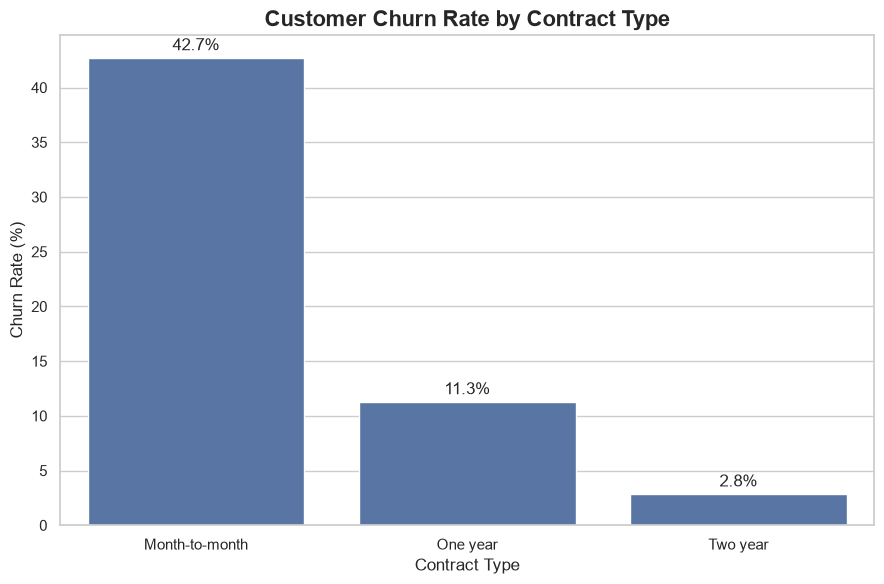

In [8]:
contract_churn = calculate_churn_rate(df, "Contract")

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=contract_churn,
    x="Contract",
    y="ChurnRate"
)

plt.title(
    "Customer Churn Rate by Contract Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_01_contract_churn_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Contract type shows a strong difference in customer churn behavior. Month-to-month customers have substantially higher churn than customers on longer-term contracts. This suggests that contract commitment is an important customer-retention factor in this dataset.

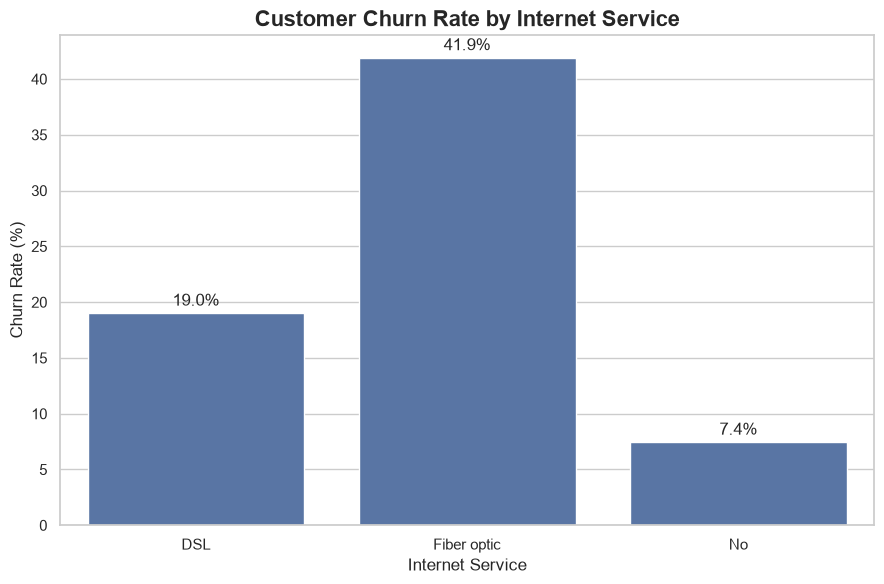

In [9]:
internet_churn = calculate_churn_rate(
    df,
    "InternetService"
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="ChurnRate"
)

plt.title(
    "Customer Churn Rate by Internet Service",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_02_internet_churn_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

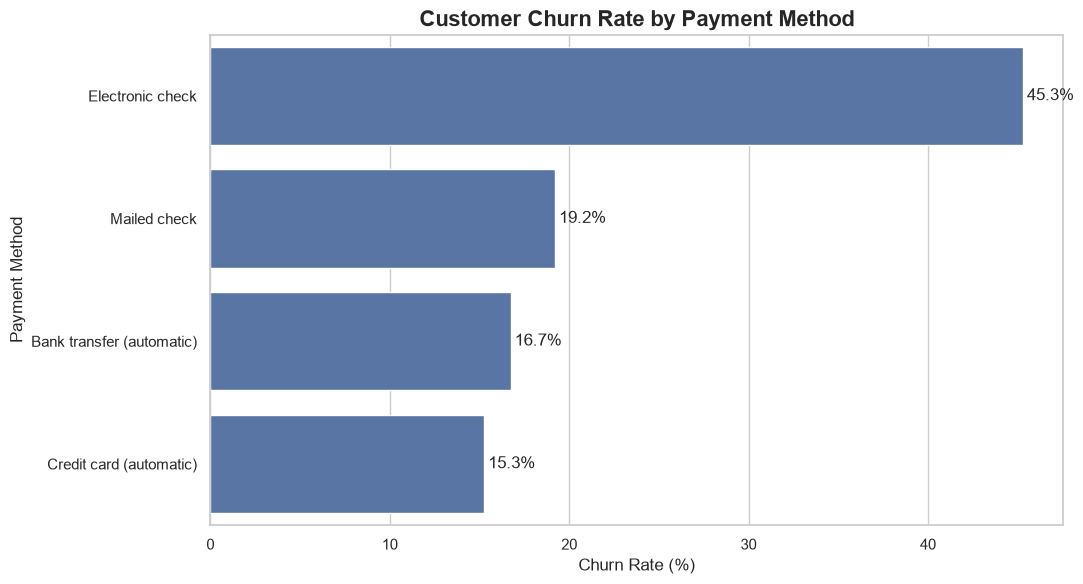

In [10]:
payment_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

payment_churn = payment_churn.sort_values(
    "ChurnRate",
    ascending=False
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=payment_churn,
    x="ChurnRate",
    y="PaymentMethod"
)

plt.title(
    "Customer Churn Rate by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_03_payment_churn_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

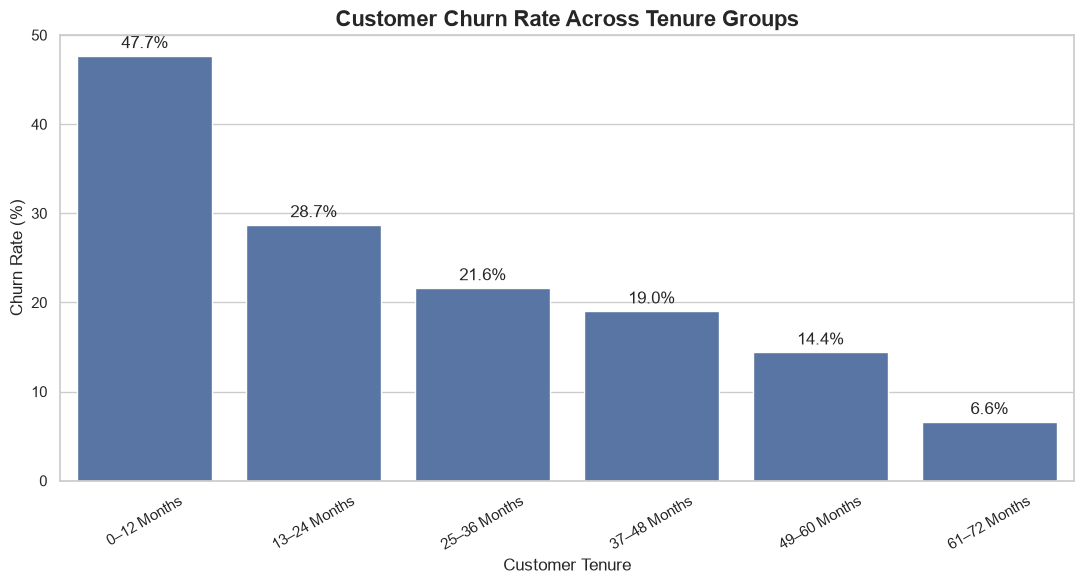

In [11]:
tenure_churn = calculate_churn_rate(
    df,
    "TenureGroup"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnRate"
)

plt.title(
    "Customer Churn Rate Across Tenure Groups",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_04_tenure_churn_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

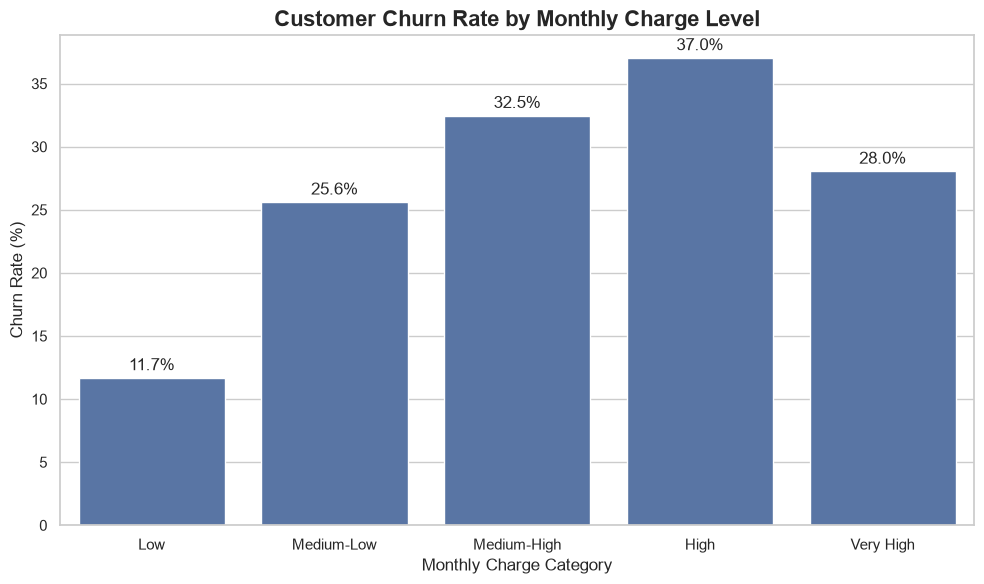

In [12]:
monthly_churn = calculate_churn_rate(
    df,
    "MonthlyChargeGroup"
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=monthly_churn,
    x="MonthlyChargeGroup",
    y="ChurnRate"
)

plt.title(
    "Customer Churn Rate by Monthly Charge Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Monthly Charge Category")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_05_monthly_charge_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

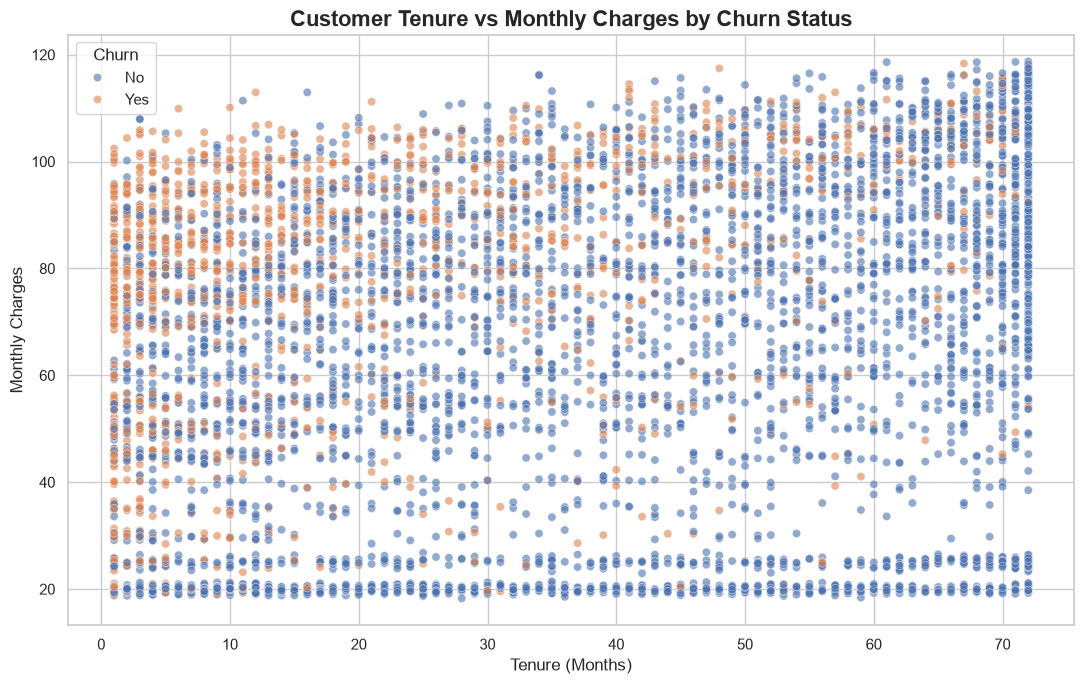

In [13]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title(
    "Customer Tenure vs Monthly Charges by Churn Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_06_tenure_vs_charges_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Are customers with particular combinations of tenure and monthly charges more frequently associated with churn?

In [14]:
df["RiskProfile"] = np.select(
    [
        (df["Contract"] == "Month-to-month") &
        (df["tenure"] <= 12),

        (df["Contract"] == "Month-to-month") &
        (df["MonthlyCharges"] >= 70),

        (df["tenure"] > 24) &
        (df["Contract"].isin(["One year", "Two year"]))
    ],
    [
        "High Attention",
        "Charge Sensitive",
        "Established Customer"
    ],
    default="General"
)

df["RiskProfile"].value_counts()

RiskProfile
Established Customer    2689
High Attention          1994
Charge Sensitive        1244
General                 1105
Name: count, dtype: int64

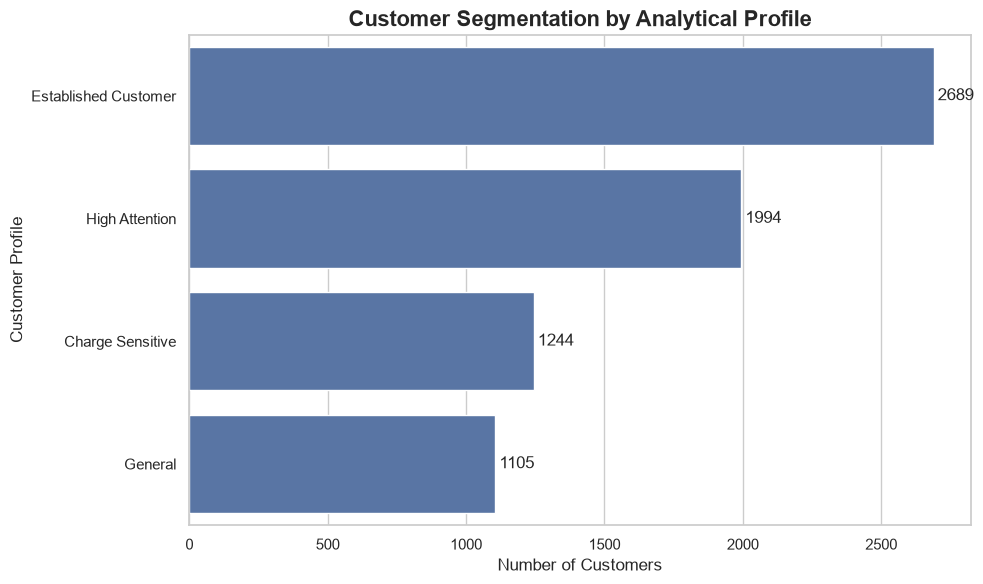

In [15]:
risk_counts = df["RiskProfile"].value_counts().reset_index()

risk_counts.columns = [
    "RiskProfile",
    "CustomerCount"
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=risk_counts,
    x="CustomerCount",
    y="RiskProfile"
)

plt.title(
    "Customer Segmentation by Analytical Profile",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Customer Profile")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()

plt.savefig(
    "../visualizations/week2_07_customer_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Week 2 — Advanced Visualization & Storytelling: Remaining Charts

The following cells extend the existing Week 2 notebook. They use the same `df`, `calculate_churn_rate`, `TenureGroup`, and `MonthlyChargeGroup` already created above.


In [16]:
# Create the Week 2 visualization directory if it does not already exist
Path("../visualizations").mkdir(parents=True, exist_ok=True)

# Analytical customer profile
df["RiskProfile"] = np.select(
    [
        (df["Contract"] == "Month-to-month") & (df["tenure"] <= 12),
        (df["Contract"] == "Month-to-month") & (df["MonthlyCharges"] >= 70),
        (df["tenure"] > 24) & (df["Contract"].isin(["One year", "Two year"]))
    ],
    [
        "High Attention",
        "Charge Sensitive",
        "Established Customer"
    ],
    default="General"
)

print("Week 2 analytical variables created.")


Week 2 analytical variables created.


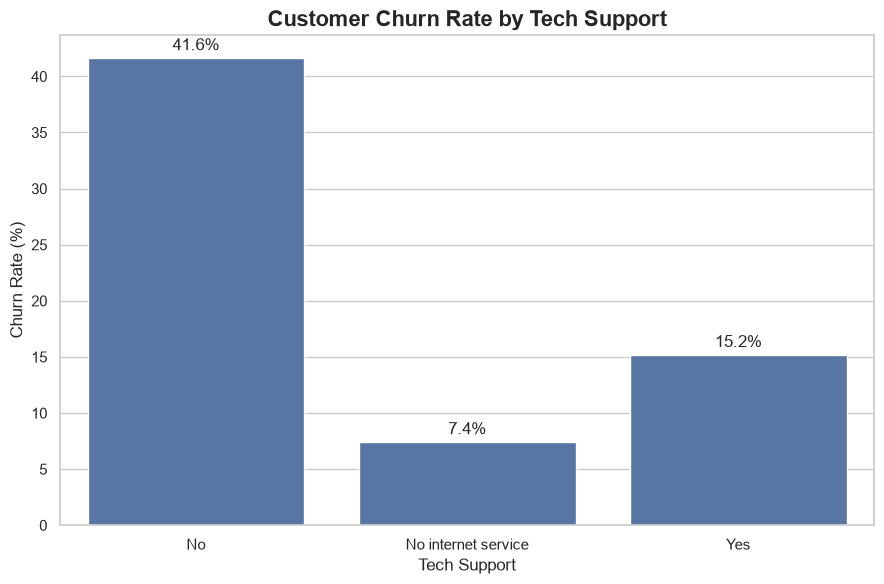

           TechSupport  ChurnRate
0                   No  41.647465
1  No internet service   7.434211
2                  Yes  15.196078


In [17]:
# Chart 8 — Churn Rate by Tech Support
tech_churn = calculate_churn_rate(df, "TechSupport")

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=tech_churn, x="TechSupport", y="ChurnRate")
plt.title("Customer Churn Rate by Tech Support", fontsize=16, fontweight="bold")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../visualizations/week2_08_tech_support_churn.png", dpi=300, bbox_inches="tight")
plt.show()

print(tech_churn)


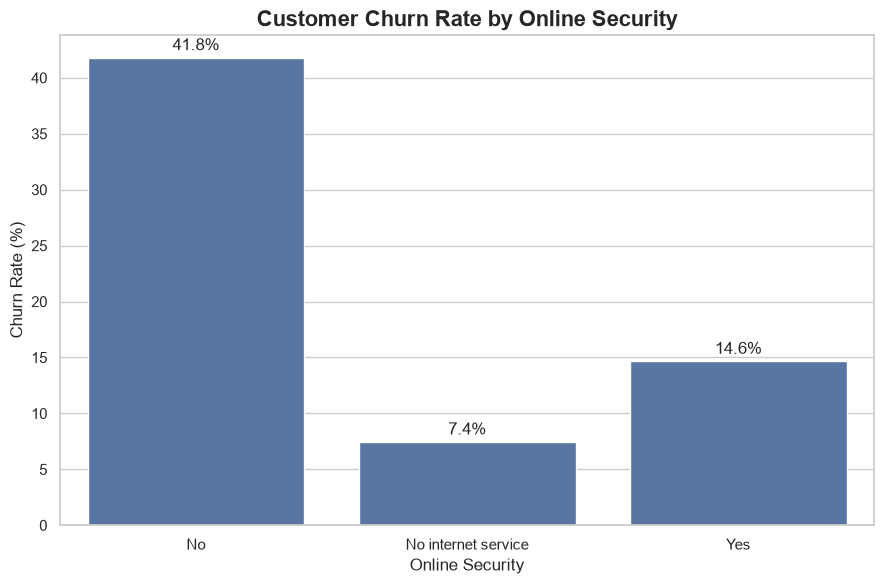

        OnlineSecurity  ChurnRate
0                   No  41.778667
1  No internet service   7.434211
2                  Yes  14.640199


In [18]:
# Chart 9 — Churn Rate by Online Security
security_churn = calculate_churn_rate(df, "OnlineSecurity")

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=security_churn, x="OnlineSecurity", y="ChurnRate")
plt.title("Customer Churn Rate by Online Security", fontsize=16, fontweight="bold")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../visualizations/week2_09_online_security_churn.png", dpi=300, bbox_inches="tight")
plt.show()

print(security_churn)


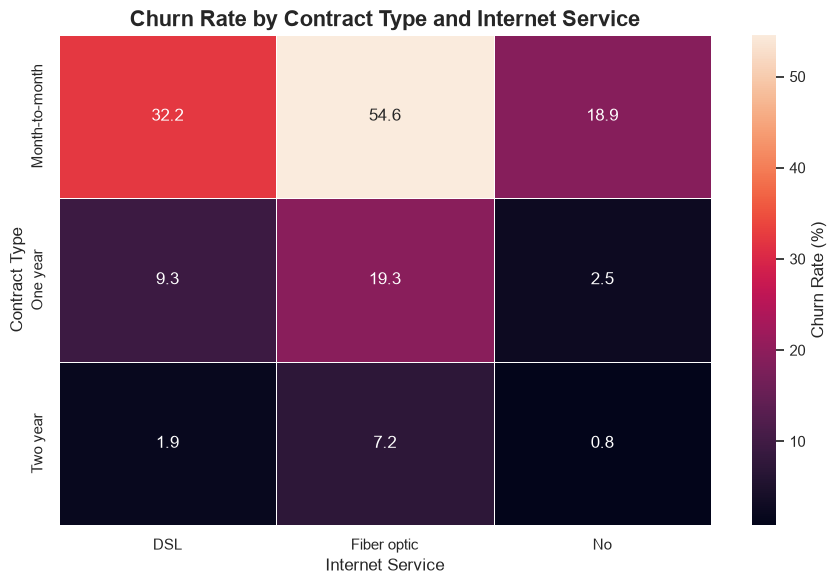

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   32.22        54.61  18.89
One year          9.30        19.29   2.48
Two year          1.93         7.23   0.79


In [19]:
# Chart 10 — Churn Rate by Contract and Internet Service
# This heatmap shows the observed churn percentage for each combination.

heatmap_data = pd.crosstab(
    df["Contract"],
    df["InternetService"],
    values=(df["Churn"] == "Yes").astype(int),
    aggfunc="mean"
) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Churn Rate by Contract Type and Internet Service",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")
plt.tight_layout()
plt.savefig("../visualizations/week2_10_contract_internet_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print(heatmap_data.round(2))


## Data Storytelling Summary

For each major visualization, use the sequence:

**Question → Visualization → Observation → Interpretation → Business Implication**

Important: these charts describe associations in the dataset. They do not establish that a particular customer characteristic causes churn.


In [20]:
# Generate a compact Week 2 summary table
summary_rows = []

for column in ["Contract", "InternetService", "PaymentMethod",
               "TenureGroup", "MonthlyChargeGroup",
               "TechSupport", "OnlineSecurity"]:
    temp = calculate_churn_rate(df, column)
    highest = temp.loc[temp["ChurnRate"].idxmax()]
    lowest = temp.loc[temp["ChurnRate"].idxmin()]
    summary_rows.append({
        "Dimension": column,
        "Highest_Churn_Group": highest[column],
        "Highest_Churn_Rate": round(highest["ChurnRate"], 2),
        "Lowest_Churn_Group": lowest[column],
        "Lowest_Churn_Rate": round(lowest["ChurnRate"], 2)
    })

week2_summary = pd.DataFrame(summary_rows)
week2_summary


,Dimension,Highest_Churn_Group,Highest_Churn_Rate,Lowest_Churn_Group,Lowest_Churn_Rate
0,Contract,Month-to-month,42.71,Two year,2.85
1,InternetService,Fiber optic,41.89,No,7.43
2,PaymentMethod,Electronic check,45.29,Credit card (automatic),15.25
3,TenureGroup,0–12 Months,47.68,61–72 Months,6.61
4,MonthlyChargeGroup,High,37.04,Low,11.68
5,TechSupport,No,41.65,No internet service,7.43
6,OnlineSecurity,No,41.78,No internet service,7.43


In [21]:
# Save the Week 2 summary for the report/GitHub
week2_summary.to_csv(
    "../visualizations/week2_summary_table.csv",
    index=False
)

print("Week 2 summary saved.")


Week 2 summary saved.


## Final Week 2 Deliverables

- `Week2_Visualization.ipynb`
- 10 advanced visualization outputs
- `week2_summary_table.csv`
- Week 2 data-storytelling report
- Business interpretation and limitations

The notebook is now ready for Week 2 execution from top to bottom.
